# Analysing results for given cell type.

## Prepare Notebook.

#### Import Libraries.

In [1]:
from collections import defaultdict
import os
import sys
import yaml

from hydra import initialize, compose
from matplotlib import cm, colors
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import torch
from tqdm.auto import tqdm

from labcompass.constants import ParamsFields

### Constants and paths.

In [2]:
ANNOTATION_CONF_DIR = "../../../../generative_modeling/conditional_flow_matching/config/annotation/default.yaml"
# CANDIDATES_CSV_PATH = "../../../../project_folder/csv_files_new_target/candidates_with_eval.csv"
CANDIDATES_CSV_PATH = "../../../../project_folder/csv_files_new_targets/candidates_with_eval.csv"
RESULTS_DIR = "../../../../project_folder/results_new"
UNIQUE_CONC_H5AD_PATH = "../../../../project_folder/unique_concentrations_adata.h5ad"
BASE_DIR = "../../../.."
TARGET_CT = "MgkPro"
TARGET_CT = "EryPro"
# TARGET_CT = "CyclingProgenitor*"

CONFIG_DIR = "../config"
CONFIG_NAME = "run_inverse"

CELL_STATE_REP = "X_channel_standardized+X_scatter_standardized"
CONDITION_REP = "condition_concat"

### Import additional modules.

In [3]:
sys.path.insert(0, f"../experiments")
from experiment_utils import get_forward_model, create_dir
from plot_utils import (
    get_adata_from_idx,
    plot_adata,
)

sys.path.insert(0, os.path.join(BASE_DIR, "scripts"))
from data_utils import get_protocol_tranformations

sys.path.insert(0, os.path.join(BASE_DIR, "/inverse/experiments"))
from experiment_utils import get_forward_model, create_dir
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel
from plot_utils import get_adata_from_idx, plot_adata


### Utility Functions.

In [4]:
def get_rescaling(
    adata: sc.AnnData,
    channel_params_key: str = "X_channel_params", 
    scatter_params_key: str = "X_scatter_params",
    inverse: bool = False,
) -> ZNorm | IZNorm:
    X_channel_params_fwd = adata.uns[channel_params_key]
    X_scatter_params_fwd = adata.uns[scatter_params_key]
    params = {
        ParamsFields.MEAN: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd[ParamsFields.MEAN],
                    X_scatter_params_fwd[ParamsFields.MEAN]
                ), axis=0
            )
        ),
        ParamsFields.COVARIANCE: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd["std"],
                    X_scatter_params_fwd["std"]
                ), axis=0
            )
        ),
    }
    if inverse:
        return IZNorm(params)
    return ZNorm(params)


def flatten_conf(conf_dict):
    return_dict = {}
    for key, value in conf_dict.items():
        if isinstance(value, dict):
            update_dict = {f"{key}:{k}": v for k, v in flatten_conf(value).items()}
        else:
            update_dict = {key: value}
        return_dict.update(update_dict)
    return return_dict


def map_df(df, transforms_dict):
    transformed_data_df = {}
    for mol, trnsf in transforms_dict.items():
        val = df.loc[:, mol].values
        if trnsf is not None:
            val = trnsf(val)
        transformed_data_df[mol] = val
    return pd.DataFrame(transformed_data_df, index=df.index)

## Load Models.

### Initialize base config and load models.

In [5]:
with initialize(config_path=CONFIG_DIR, version_base=None):
    base_cfg = compose(config_name=CONFIG_NAME)
forward_model, (
    perturbation_response_prediction_model,
    target_prediction_model,
) = get_forward_model(base_cfg, logger=None)


### Parsing data objects from the models.

In [6]:
train_adata_phi = perturbation_response_prediction_model.train_data.adata
val_adata_phi = perturbation_response_prediction_model.validation_data[0].adata
print(f"{train_adata_phi=}\n{val_adata_phi=}")

train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
print(f"{train_adata_g=}\n{val_adata_g=}")


train_adata_phi=AnnData object with n_obs × n_vars = 92953367 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_

### Subsampling data from forward model.

In [7]:
n_train_cells = 70_000
n_val_cells = 30_000
train_adata_phi = sc.pp.sample(
    train_adata_phi,
    n=n_train_cells,
    copy=True
)
val_adata_phi = sc.pp.sample(
    val_adata_phi,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_phi=}, {val_adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one

### Concatenating and computing PCs and neighbors.

In [8]:
adata_g = sc.concat((train_adata_g, val_adata_g), uns_merge="same")
adata_g

adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
sc.pp.pca(adata_phi)
sc.pp.neighbors(adata_phi)
sc.tl.umap(adata_phi)
adata_phi

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng_ml]_one_hot', 'butyzamide_[nm]_one_h

### Rescaling data.

In [9]:
izn_g = get_rescaling(train_adata_g, inverse=True)
zn_phi = get_rescaling(train_adata_phi)
X_true = torch.from_numpy(adata_g.obsm[CELL_STATE_REP]).float().cuda()
X_true = izn_g(X_true)
X_true = zn_phi(X_true).detach().cpu().numpy()
adata_g.obsm["rescaled_features"] = X_true
adata_g

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_scatter', 'X_scatter_standardized', 'X_channel', 'X_channel_standardized', 'X_channel+X_scatter', 'X_channel_standardized+X_scatter'

### Read annotation configurations.

In [10]:
with open(ANNOTATION_CONF_DIR, "r") as fb:
    ann_cdict = yaml.safe_load(fb)

### Read file with unique concentrations.

In [11]:
adata_conc = sc.read_h5ad(UNIQUE_CONC_H5AD_PATH)
adata_conc

AnnData object with n_obs × n_vars = 117 × 15
    obs: 'CD14-Mono', 'CD49c-Myeloid', 'CyclingProgenitor', 'DCs-CD14', 'EarlyGMP', 'Early_Pro-B', 'EosBasoMastPre', 'EosBasoMastPre_2', 'EryPro', 'GMP-Cycle', 'GMP-Neutro', 'GMP-Neutro_CD16-Mono', 'HSCs', 'MEP', 'MLP', 'MPP', 'MgkPro', 'Pro-B', 'pDCs_cDCs'

### Load transformations.

In [12]:
column2tranform = get_protocol_tranformations(
    ann_cdict["protocol_columns"],
    log1p_exp_cols=ann_cdict["log1p_exp_cols"],
    log21p_exp_cols=ann_cdict["log21p_exp_cols"],
    inverse=False
)
len(column2tranform)
icolumn2tranform = get_protocol_tranformations(
    ann_cdict["protocol_columns"],
    log1p_exp_cols=ann_cdict["log1p_exp_cols"],
    log21p_exp_cols=ann_cdict["log21p_exp_cols"],
    inverse=True
)
len(column2tranform)


15

### Transforming measure concentrations.

In [13]:
transformed_data_conc_df = pd.DataFrame(
    adata_conc.X,
    columns=adata_conc.var_names,
    index=adata_conc.obs.index
)
data_conc_df = map_df(transformed_data_conc_df, icolumn2tranform)
data_conc_df

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
0,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,13.0
1,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,14.0
2,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,15.0
3,5.0,100.0,10.0,0.0,0.0,0.0,0.0,1.5,0.0,100.0,0.0,0.0,0.0,20.0,21.0
4,5.0,100.0,10.0,0.0,0.0,0.0,70.0,0.0,0.0,100.0,0.0,0.0,0.0,20.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,1.0,0.0,0.0,20.0,14.0
113,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,1.0,0.0,0.0,20.0,21.0
114,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,5.0,0.0,0.0,20.0,14.0
115,5.0,100.0,10.0,10.0,2.5,750.0,1120.0,0.0,50.0,0.0,5.0,0.0,0.0,20.0,21.0


### Computing the bounds on the data.


In [14]:
data_conc_min = data_conc_df.min(0)
data_conc_max = data_conc_df.max(0)

### Prepare Label encoder.

In [15]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

## Load results.

### Load results for cell type.

In [16]:
TARGET_CT = "EryPro"

# prepare paths for target cell type
target_ct_dir = os.path.join(RESULTS_DIR, TARGET_CT)
runs = os.listdir(target_ct_dir)
runs_dir = [os.path.join(target_ct_dir, run) for run in runs]

# prepare store for results
df_idx = []
conf_df = defaultdict(list)
fwd_rdict = {}
inv_rdict = {}

# define progress bar
pbar = tqdm(range(len(runs_dir)))

# iterate over the runs
for idx, rdir in enumerate(runs_dir):
    # skip not directory
    if not os.path.isdir(rdir):
        continue

    # update progress bar
    run_id = runs[idx]
    pbar.set_description(
        f"{run_id=}"
    )
    pbar.update()

    # configuration file
    with open(os.path.join(rdir, "config.yaml"), "r") as fb:
        conf_dict = yaml.safe_load(fb)
    fconf_dict = flatten_conf(conf_dict)

    # update configuration data dictionary and index
    for k, v in fconf_dict.items():
        conf_df[k].append(v)
    df_idx.append(run_id)

    # load arrays
    fwd_rdict[run_id] = np.load(os.path.join(rdir, "fwd_results.npz"))
    inv_rdict[run_id] = np.load(os.path.join(rdir, "inverse_results.npz"))

# create config data frame
conf_df = pd.DataFrame(
    conf_df,
    index=pd.Index(df_idx, name="run_id"),
)
conf_df

  0%|          | 0/63 [00:00<?, ?it/s]

,forward_model:num_time_steps,forward_model:solver_kwargs:method,loss_guidance:fix_noise,loss_guidance:num_forward_pass_per_sample,loss_guidance:regularization,loss_guidance:reg_strength,loss_guidance:n_time_steps_forward_model,loss_guidance:solver_kwargs_forward_model:method,non_linearity:non_linearity_id,non_linearity:non_linearity_kwargs,...,sampling:num_time_steps,sampling:solver_kwargs:method,sampling:sde_sampling,sampling:mask_gradients,scheduler:scheduler_id,scheduler:scheduler_kwargs:lambda_val,scheduler:scheduler_kwargs:lmin,scheduler:scheduler_kwargs:lmax,scheduler:scheduler_kwargs:gamma,optimized_metric
run_id,,,,,,,,,,,,,,,,,,,,,
2026-01-21_21-27-50_94ee9e6a,1000,euler,True,350,None,0.0,50,euler,relu,None,...,500,euler,False,False,exp-decay,None,0.0,5.0,5.0,all_conditions_wasserstein_distance
2026-01-21_19-49-42_46f0ed79,1000,euler,True,350,None,0.0,50,euler,relu,None,...,100,euler,False,False,reciprocal,None,0.0,1.0,1.0,all_conditions_wasserstein_distance
2026-01-21_17-29-12_50efd544,1000,euler,True,350,None,0.0,50,euler,relu,None,...,100,euler,False,False,constant,None,0.0,5.0,1.0,all_conditions_wasserstein_distance
2026-01-21_14-36-05_dbfdfc31,1000,euler,True,350,None,0.0,50,euler,relu,None,...,500,euler,False,False,constant,None,0.0,1.0,1.0,all_conditions_wasserstein_distance
2026-01-21_21-19-36_bffbaa9e,1000,euler,True,350,None,0.0,50,euler,relu,None,...,100,euler,False,False,exp-decay,None,0.0,7.0,1.0,all_conditions_wasserstein_distance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-21_21-08-05_680597f6,1000,euler,True,350,None,0.0,50,euler,relu,None,...,100,euler,False,False,exp-decay,None,0.0,1.0,2.0,all_conditions_wasserstein_distance
2026-01-21_18-53-23_7570bbe7,1000,euler,True,350,None,0.0,50,euler,relu,None,...,200,euler,False,False,lin-decay,None,0.0,5.0,1.0,all_conditions_wasserstein_distance
2026-01-21_21-04-25_ea822de7,1000,euler,True,350,None,0.0,50,euler,relu,None,...,200,euler,False,False,exp-decay,None,0.0,5.0,1.0,all_conditions_wasserstein_distance


### Read annotated results `.csv` file.

In [17]:
# read data frame
candidates_df = pd.read_csv(CANDIDATES_CSV_PATH)

# parse column
target_ct = candidates_df["sample_id"].map(lambda e: e.split(":")[0])
run_id = candidates_df["sample_id"].map(lambda e: e.split(":")[1])
sample_id = candidates_df["sample_id"].map(lambda e: e.split(":")[2])

# construct index
index_df = pd.DataFrame(
    {
        "target_ct": target_ct,
        "run_id": run_id,
        "sample_id": sample_id
    }
)
midx = pd.MultiIndex.from_frame(index_df)
candidates_df = candidates_df.set_index(midx)


### Transforming candidates.

In [18]:
transformed_candidates_df = map_df(candidates_df, column2tranform)
transformed_candidates_df.head()

740-yp_[µm]  mtg_[µm]  \
target_ct run_id                       sample_id                          
HSCs      2026-01-21_19-39-07_4bd2367a 0             5.557746  6.225809   
                                       1             6.192060  4.141162   
                                       2             3.798582  3.996689   
                                       3             4.560554  3.741201   
                                       4             5.212351  3.855234   

                                                  rhflt3l_[ng_ml]  \
target_ct run_id                       sample_id                    
HSCs      2026-01-21_19-39-07_4bd2367a 0                 0.686280   
                                       1                 1.138092   
                                       2                 2.759209   
                                       3                 2.637978   
                                       4                 3.094908   

                                                  gm-csf_[ng_ml]  tpo_[ng_ml]  \
target_ct run_id                       sample_id                                
HSCs      2026-01-21_19-39-07_4bd2367a 0                3.693768     0.906367   
                                       1                2.161569     1.575356   
                                       2                2.840903     2.036012   
                                       3                2.247957     0.000000   
                                       4                1.602161     1.968344   

                                                  sr1_[nm]  um171_[nm]  \
target_ct run_id                       sample_id                         
HSCs      2026-01-21_19-39-07_4bd2367a 0          6.695187    6.324843   
                                       1          8.870637    4.739231   
                                       2          6.689921    0.000000   
                                       3          3.759237    4.355074   
                                       4          4.851290    6.664627   

                                                  um729_[µm]  scf_[ng_ml]  \
target_ct run_id                       sample_id                            
HSCs      2026-01-21_19-39-07_4bd2367a 0            0.000000     3.786086   
                                       1            0.000000     5.167915   
                                       2            6.583070     5.287112   
                                       3            0.366849     1.474910   
                                       4            0.000000     3.717473   

                                                  butyzamide_[nm]  \
target_ct run_id                       sample_id                    
HSCs      2026-01-21_19-39-07_4bd2367a 0                 0.000000   
                                       1                 0.000000   
                                       2                 0.000000   
                                       3                 5.449202   
                                       4                 1.005472   

                                                  retinoic_acid_[µm]  \
target_ct run_id                       sample_id                       
HSCs      2026-01-21_19-39-07_4bd2367a 0                    0.000000   
                                       1                    0.452664   
                                       2                    0.099409   
                                       3                    0.000000   
                                       4                    0.286964   

                                                  ldl_[ng_ml]  il3_[ng_ml]  \
target_ct run_id                       sample_id                             
HSCs      2026-01-21_19-39-07_4bd2367a 0             0.000000     0.000000   
                                       1            11.160040     0.000000   
                                       2             0.302339     0.000000   
                                  

### Join the two data frames for the target cell type.

In [19]:
# select results for target cell type only
ct_candidates_df = candidates_df.loc[TARGET_CT]
ct_candidates_df.head()

# join the data frame
ct_results_df = ct_candidates_df.join(conf_df, on="run_id")
ct_results_df.head()

sample_id  \
run_id                       sample_id                                          
2026-01-21_19-49-42_46f0ed79 0          EryPro:2026-01-21_19-49-42_46f0ed79:0   
                             1          EryPro:2026-01-21_19-49-42_46f0ed79:1   
                             2          EryPro:2026-01-21_19-49-42_46f0ed79:2   
                             3          EryPro:2026-01-21_19-49-42_46f0ed79:3   
                             4          EryPro:2026-01-21_19-49-42_46f0ed79:4   

                                        740-yp_[µm]    mtg_[µm]  \
run_id                       sample_id                            
2026-01-21_19-49-42_46f0ed79 0             5.469761  434.206200   
                             1             6.168861   45.828780   
                             2             3.726757   50.587494   
                             3             4.560882   60.117584   
                             4             5.501544   55.129810   

                                        rhflt3l_[ng_ml]  gm-csf_[ng_ml]  \
run_id                       sample_id                                    
2026-01-21_19-49-42_46f0ed79 0                 1.162042       38.940983   
                             1                 4.365069       13.874820   
                             2                19.720127       10.515271   
                             3                13.475098       10.591624   
                             4                20.905968        6.285308   

                                        tpo_[ng_ml]    sr1_[nm]   um171_[nm]  \
run_id                       sample_id                                         
2026-01-21_19-49-42_46f0ed79 0             1.030975   560.60410   276.639160   
                             1             2.417176  5235.20170    68.884460   
                             2             3.939743   644.46265     0.403029   
                             3             1.662931   282.91420  1234.836000   
                             4             3.134843   184.16312   863.617860   

                                        um729_[µm]  scf_[ng_ml]  ...  \
run_id                       sample_id                           ...   
2026-01-21_19-49-42_46f0ed79 0            0.000000    27.102770  ...   
                             1            0.000000   127.393670  ...   
                             2            2.546462   176.092470  ...   
                             3            0.000000    35.592926  ...   
                             4            0.041300    21.583351  ...   

                                        sampling:num_time_steps  \
run_id                       sample_id                            
2026-01-21_19-49-42_46f0ed79 0                              100   
                             1                              100   
                             2                              100   
                             3                              100   
                             4                              100   

                                        sampling:solver_kwargs:method  \
run_id                       sample_id                                  
2026-01-21_19-49-42_46f0ed79 0                                  euler   
                             1                                  euler   
                             2                                  euler   
                             3                                  euler   
                             4                                  euler   

                                        sampling:sde_sampling  \
run_id                       sample_id                          
2026-01-21_19-49-42_46f0ed79 0                          False   
                             1                          False   
                             2                          False   
                             3                          False   
                             4                          False   



### Retrieve columns of interest.

In [20]:
protocol_cols = ann_cdict["protocol_columns"]
scheduler_cols = [col for col in ct_results_df.columns if col.startswith("scheduler")]
mrs_cols = [col for col in ct_results_df.columns if col.startswith("MRS")]
mrs_cols = [col for col in ct_results_df.columns if col.startswith("wmus")]
constraints_cols = [col for col in ct_results_df.columns if col.startswith("constraint")]
ct_prop_cols = [col for col in ct_results_df.columns if col.endswith("prop")]

### Cluster the results.

In [21]:
# Standardize or scale if needed
df_protocol = ct_results_df[protocol_cols].copy()
df_protocol_scaled = (df_protocol - df_protocol.min()) / (df_protocol.max() - df_protocol.min())

# Hierarchical clustering of rows
Z = linkage(df_protocol_scaled, method='ward', metric='euclidean')

# Optional: define number of clusters
n_clusters = 6
clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
# clusters = fcluster(Z, criterion='maxclust')

# Add cluster labels to original df
df_protocol_scaled['cluster'] = clusters
df_protocol_scaled

740-yp_[µm]  mtg_[µm]  \
run_id                       sample_id                          
2026-01-21_19-49-42_46f0ed79 0             0.395207  0.002713   
                             1             0.470503  0.000280   
                             2             0.207478  0.000310   
                             3             0.297317  0.000370   
                             4             0.398631  0.000339   
...                                             ...       ...   
2026-01-21_14-53-49_8d3999e8 120           0.322232  0.000893   
                             121           0.326505  0.001163   
                             122           0.365426  0.000689   
                             123           0.362304  0.003267   
                             124           0.292221  0.000846   

                                        rhflt3l_[ng_ml]  gm-csf_[ng_ml]  \
run_id                       sample_id                                    
2026-01-21_19-49-42_46f0ed79 0                 0.001414        0.003534   
                             1                 0.005313        0.001259   
                             2                 0.024004        0.000954   
                             3                 0.016402        0.000961   
                             4                 0.025448        0.000570   
...                                                 ...             ...   
2026-01-21_14-53-49_8d3999e8 120               0.007391        0.000938   
                             121               0.002504        0.003495   
                             122               0.013916        0.001139   
                             123               0.000000        0.003778   
                             124               0.027290        0.001349   

                                        tpo_[ng_ml]  sr1_[nm]  um171_[nm]  \
run_id                       sample_id                                      
2026-01-21_19-49-42_46f0ed79 0             0.072499  0.001746    0.023217   
                             1             0.169977  0.016307    0.005781   
                             2             0.277045  0.002007    0.000034   
                             3             0.116938  0.000881    0.103636   
                             4             0.220444  0.000574    0.072481   
...                                             ...       ...         ...   
2026-01-21_14-53-49_8d3999e8 120           0.199826  0.002636    0.003925   
                             121           0.153379  0.000678    0.017887   
                             122           0.159430  0.000046    0.000000   
                             123           0.118454  0.000419    0.072443   
                             124           0.000000  0.000118    0.000000   

                                        um729_[µm]  scf_[ng_ml]  \
run_id                       sample_id                            
2026-01-21_19-49-42_46f0ed79 0            0.000000     0.000043   
                             1            0.000000     0.000201   
                             2            0.000298     0.000278   
                             3            0.000000     0.000056   
                             4            0.000005     0.000034   
...                                            ...          ...   
2026-01-21_14-53-49_8d3999e8 120          0.000015     0.000160   
                             121          0.000038     0.000006   
                             122          0.001156     0.000002   
                             123          0.002016     0.000167   
                             124          0.041496     0.000008   

                                        butyzamide_[nm]  retinoic_acid_[µm]  \
run_id                       sample_id                                        
2026-01-21_19-49-42_46f0ed79 0                 0.000000            0.000000   
                             1                 0.000000            0.132652   
                            

## Plot results.

### Group data frame by scheduler id.

In [22]:
sched_groups = ct_results_df.groupby("scheduler:scheduler_id")
const_sched_df = sched_groups.get_group("constant") # lambda val
ldec_sched_df = sched_groups.get_group("lin-decay") # lmin, lmax
# edec_sched_df = sched_groups.get_group("exp-decay") # lmin, lmax, gamma
rec_sched_df = sched_groups.get_group("reciprocal") # lmax

### Plot relation between loss and scheduler configs.

scheduler:scheduler_kwargs:lmax [np.float64(1.0), np.float64(3.0), np.float64(5.0), np.float64(7.0)] [(0.253935, 0.265254, 0.529983), (0.163625, 0.471133, 0.558148), (0.134692, 0.658636, 0.517649), (0.477504, 0.821444, 0.318195)]
scheduler:scheduler_kwargs:lmax [np.float64(1.0), np.float64(5.0), np.float64(7.0)] [(0.229739, 0.322361, 0.545706), (0.127568, 0.566949, 0.550556), (0.369214, 0.788888, 0.382914)]
scheduler:scheduler_kwargs:lmax [np.float64(1.0), np.float64(5.0), np.float64(7.0)] [(0.229739, 0.322361, 0.545706), (0.127568, 0.566949, 0.550556), (0.369214, 0.788888, 0.382914)]


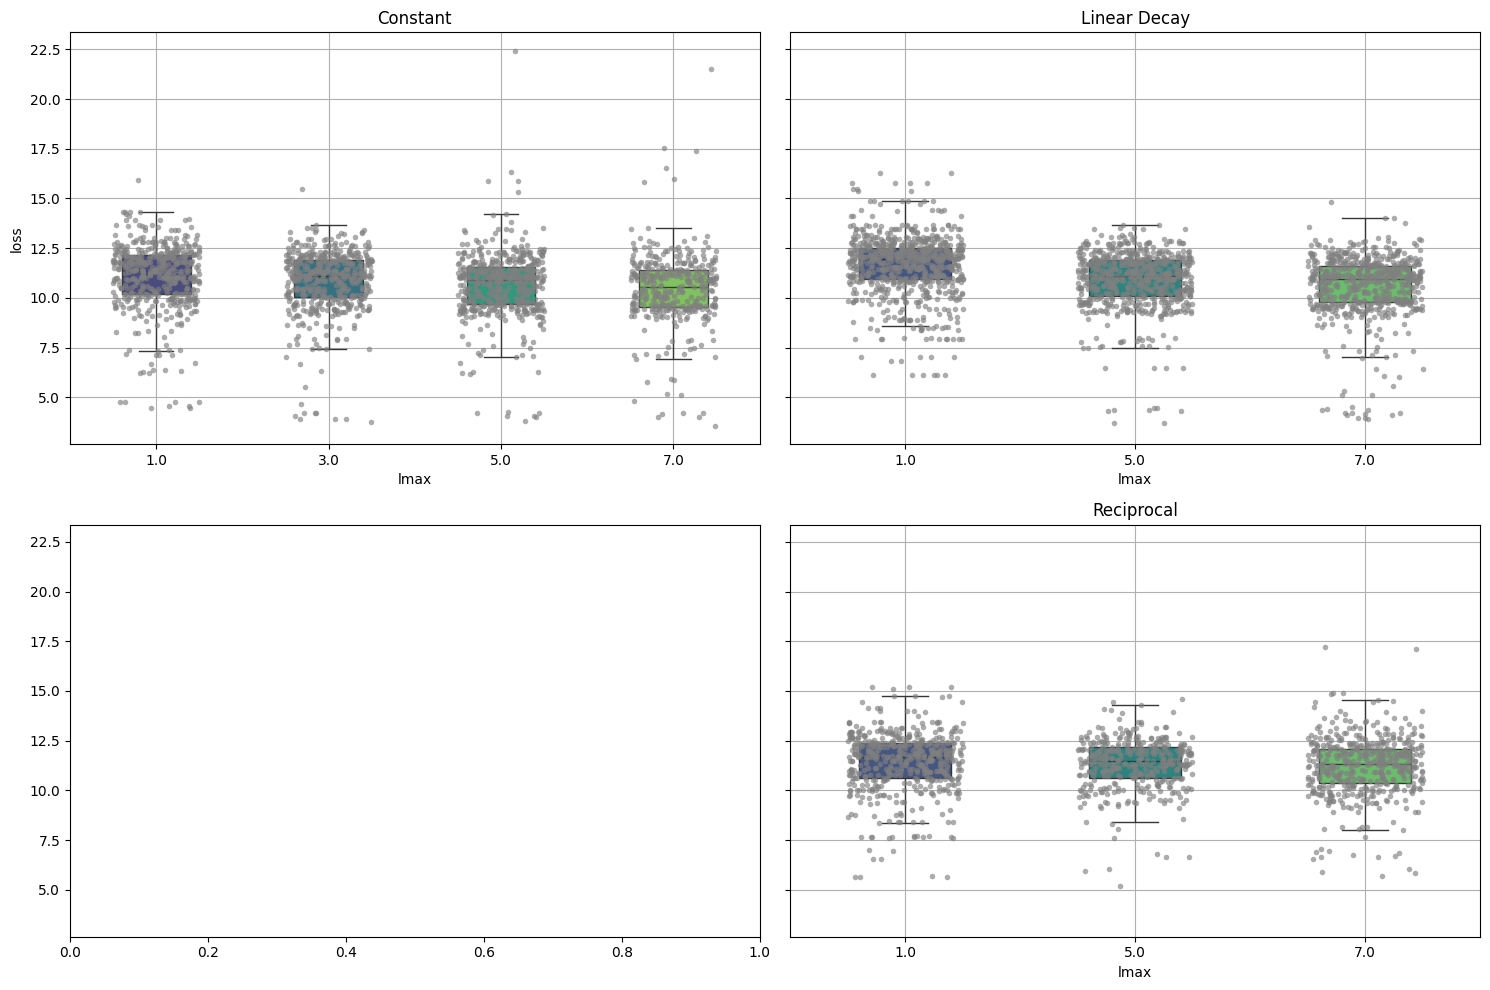

In [23]:
# prepare columns
x_cols = {
    "Constant": "scheduler:scheduler_kwargs:lmax",
    "Linear Decay": "scheduler:scheduler_kwargs:lmax",
    # "Exponential Decay": "scheduler:scheduler_kwargs:gamma",
    "Exponential Decay": "scheduler:scheduler_kwargs:lmax",
    "Reciprocal": "scheduler:scheduler_kwargs:lmax",
}
y_col = "loss"

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)

sched_data = [
    (const_sched_df, "Constant", axes[0, 0]),
    (ldec_sched_df, "Linear Decay", axes[0, 1]),
    # (edec_sched_df, "Exponential Decay", axes[1, 0]),
    (rec_sched_df, "Reciprocal", axes[1, 1]),
]

for df, title, ax in sched_data:
    x_col = x_cols[title]
    order = sorted(df[x_col].unique())
    palette = sns.color_palette("viridis", len(order))
    print(x_col, order, palette
          )
    sns.boxplot(
        data=df,
        x=x_col,
        y=y_col,
        ax=ax,
        width=0.4,
        palette=palette,
        showfliers=False,
        hue=x_col,
        legend=False
    )
    sns.stripplot(
        data=df,
        x=x_col,
        y=y_col,
        order=order,
        ax=ax,
        color="grey",
        size=4,
        jitter=0.25,
        alpha=0.65
    )

    ax.set_title(title)
    ax.set_xlabel(x_col.split(":")[-1])
    ax.set_ylabel(y_col)
    ax.grid(1)

plt.tight_layout()
plt.show()


### Plot cell type proportion by scheduler configurations.

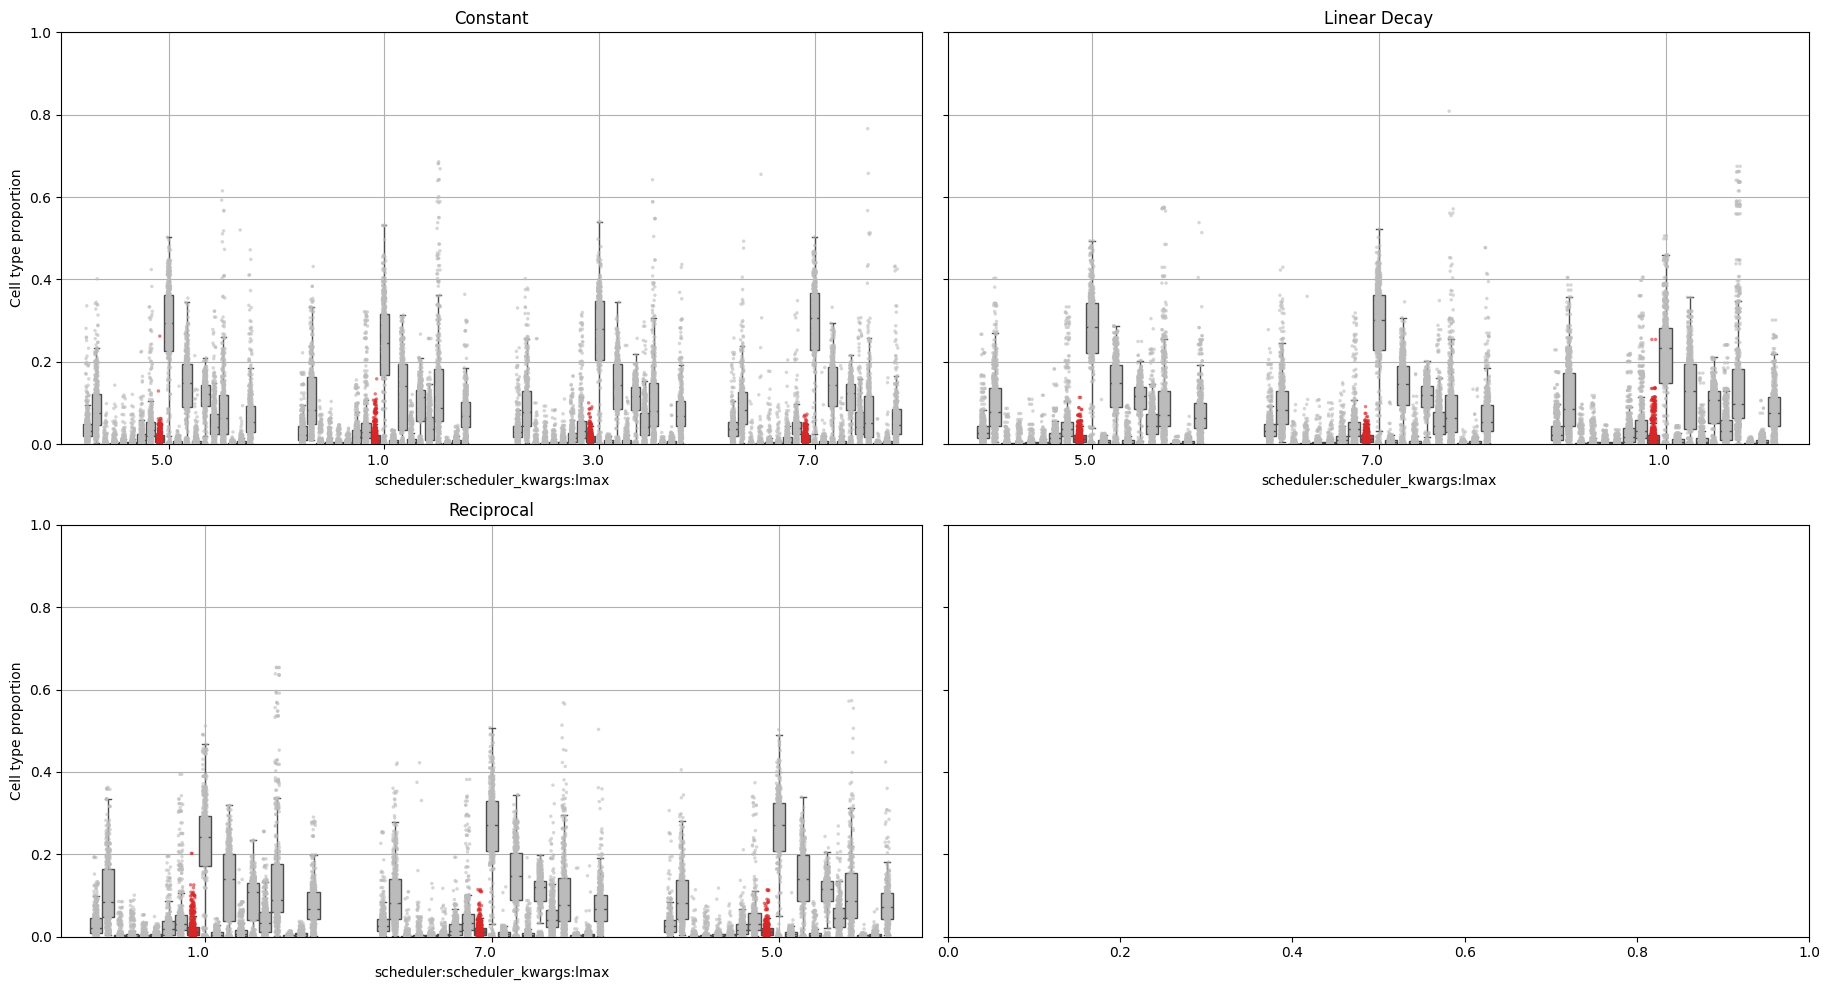

In [24]:
sched_data = [
    (const_sched_df, "Constant"),
    (ldec_sched_df, "Linear Decay"),
    # (edec_sched_df, "Exponential Decay"),
    (rec_sched_df, "Reciprocal"),
]

# -----------------------------
# FUNCTIONS
# -----------------------------
def make_palette(cell_types, target):
    palette = {ct: "#bbbbbb" for ct in cell_types}  # grey for all
    palette[target + "_prop"] = "#d62728"          # red for target
    return palette

def melt_celltype_props(df, x_col):
    long_df = df[[x_col] + ct_prop_cols].melt(
        id_vars=x_col,
        var_name="cell_type",
        value_name="proportion"
    )
    # fake spacing for x-axis to give extra space between boxes
    long_df["_x_spaced"] = long_df[x_col].astype(str) + "   "
    return long_df

# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharey=True)

for (df, title), ax in zip(sched_data, axes.flat):
    x_col = x_cols[title]
    long_df = melt_celltype_props(df, x_col)
    cell_types = long_df["cell_type"].unique()
    palette = make_palette(cell_types, TARGET_CT)

    hue_order = sorted(cell_types)

    # Boxplot
    sns.boxplot(
        data=long_df,
        x="_x_spaced",
        y="proportion",
        hue="cell_type",
        hue_order=hue_order,
        palette=palette,
        # width=0.25,
        showfliers=False,
        dodge=True,
        ax=ax
    )

    # Jittered points
    sns.stripplot(
        data=long_df,
        x="_x_spaced",
        y="proportion",
        hue="cell_type",
        hue_order=hue_order,
        dodge=True,
        palette=palette,
        size=2.5,
        jitter=0.15,
        alpha=0.6,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Cell type proportion")
    ax.set_ylim(0, 1)
    ax.grid(True)

    # Remove duplicate legend
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


### Plot the molecule concentrations per cluster.

/tmp/ipykernel_3833993/2466999404.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_3833993/2466999404.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')


740-yp_[µm] 0.34461217665348837
mtg_[µm] 0.0006197405253679652
rhflt3l_[ng_ml] 0.012172401125411519
gm-csf_[ng_ml] 0.0009075498070140715
tpo_[ng_ml] 0.17580156194765345
sr1_[nm] 0.0023361529765298854
um171_[nm] 0.0939978195862921
um729_[µm] 0.13087489516862472
scf_[ng_ml] 7.887313136932086e-05
butyzamide_[nm] 0.026244477702613015
retinoic_acid_[µm] 7.377210027694044
ldl_[ng_ml] 0.9106273195043769
il3_[ng_ml] 0.2169086825291987
o2_[%] 0.014736597322625524
days_of_culture 0.06632494947282444


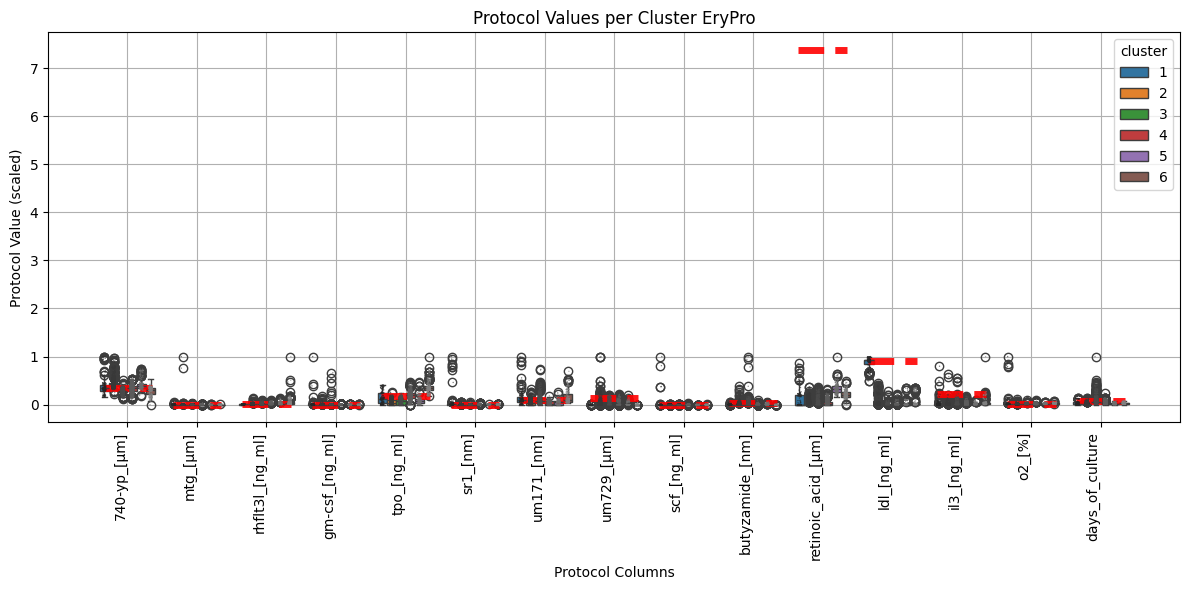

In [25]:
long_df = df_protocol_scaled.melt(
    id_vars='cluster',
    var_name='protocol',
    value_name='value'
)

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=long_df,
    x='protocol',
    y='value',
    hue='cluster',
    palette='tab10',
    legend=True
)

sns.stripplot(
    data=long_df,
    x='protocol',
    y='value',
    hue='cluster',
    color="grey",
    dodge=True,
    size=1.0,
    jitter=0.15,
    alpha=0.6,
    ax=ax,
    legend=False
)
# Rotate x-tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
ax.grid(1)

# Get category positions
protocols = ax.get_xticklabels()
x_positions = range(len(protocols))

# Width of each horizontal segment
half_width = 0.35
for x, label in zip(x_positions, protocols):
    protocol_name = label.get_text()    
    max_val = (data_conc_max[protocol_name]  - df_protocol[protocol_name].min()) / (df_protocol[protocol_name].max() - df_protocol[protocol_name].min())
    print(protocol_name, max_val)
    ax.hlines(
        y=max_val,
        xmin=x - half_width,
        xmax=x + half_width,
        colors='red',
        linestyles='dashed',
        linewidth=5,
        alpha=0.9
    )

plt.xlabel("Protocol Columns")
plt.ylabel("Protocol Value (scaled)")
plt.title(f"Protocol Values per Cluster {TARGET_CT}")
# plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Plot Performance metric per cluster.

/tmp/ipykernel_3833993/2358008733.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')


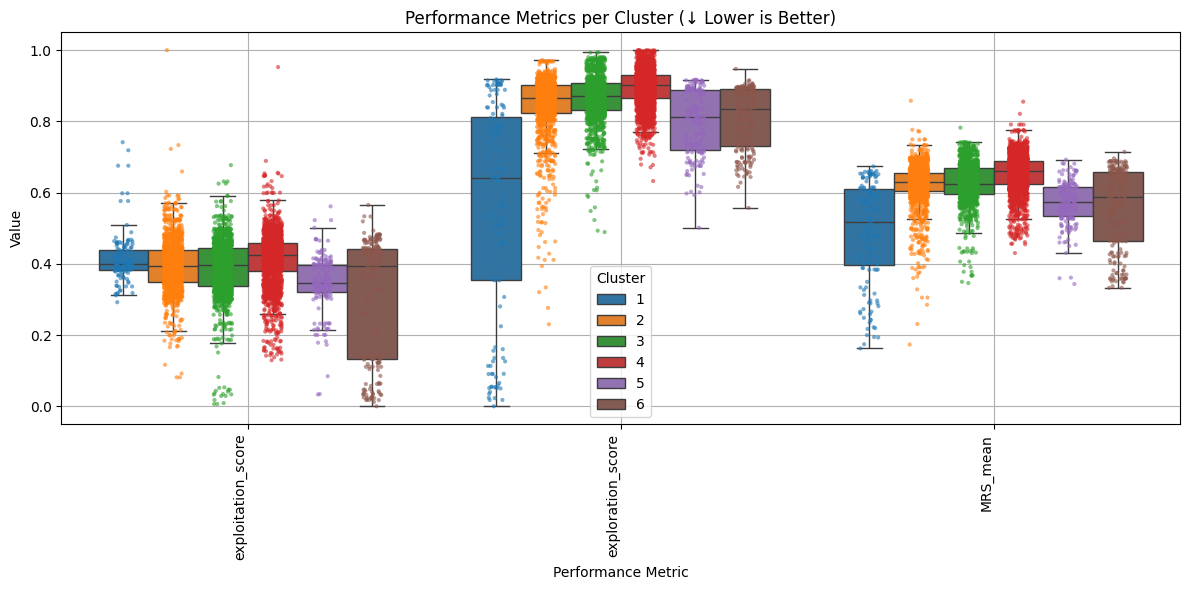

In [26]:
perf_metrics = ["exploitation_score", "exploration_score", "MRS_mean"]

# Copy the metrics
df_perf = ct_results_df[perf_metrics].copy()

# Add the cluster assignments from protocol clustering
# Assume you already have `clusters` from previous protocol clustering
df_perf['cluster'] = clusters  # reuse cluster labels

# Melt for seaborn
long_df = df_perf.melt(
    id_vars='cluster',
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=long_df,
    x='metric',
    y='value',
    hue='cluster',
    palette='tab10',
    # width=0.25,
    showfliers=False,
    dodge=True
)

# Overlay jittered points
sns.stripplot(
    data=long_df,
    x='metric',
    y='value',
    hue='cluster',
    palette='tab10',
    dodge=True,
    size=3,
    jitter=0.15,
    alpha=0.6,
    ax=ax
)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

# Clean legend: keep only one copy
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(set(clusters))], labels[:len(set(clusters))], title="Cluster")
ax.grid(1)

plt.xlabel("Performance Metric")
plt.ylabel("Value")
plt.title("Performance Metrics per Cluster (↓ Lower is Better)")
plt.tight_layout()
plt.show()


### Plot Induced Phenotype per cluster.

/tmp/ipykernel_3833993/2453470819.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')


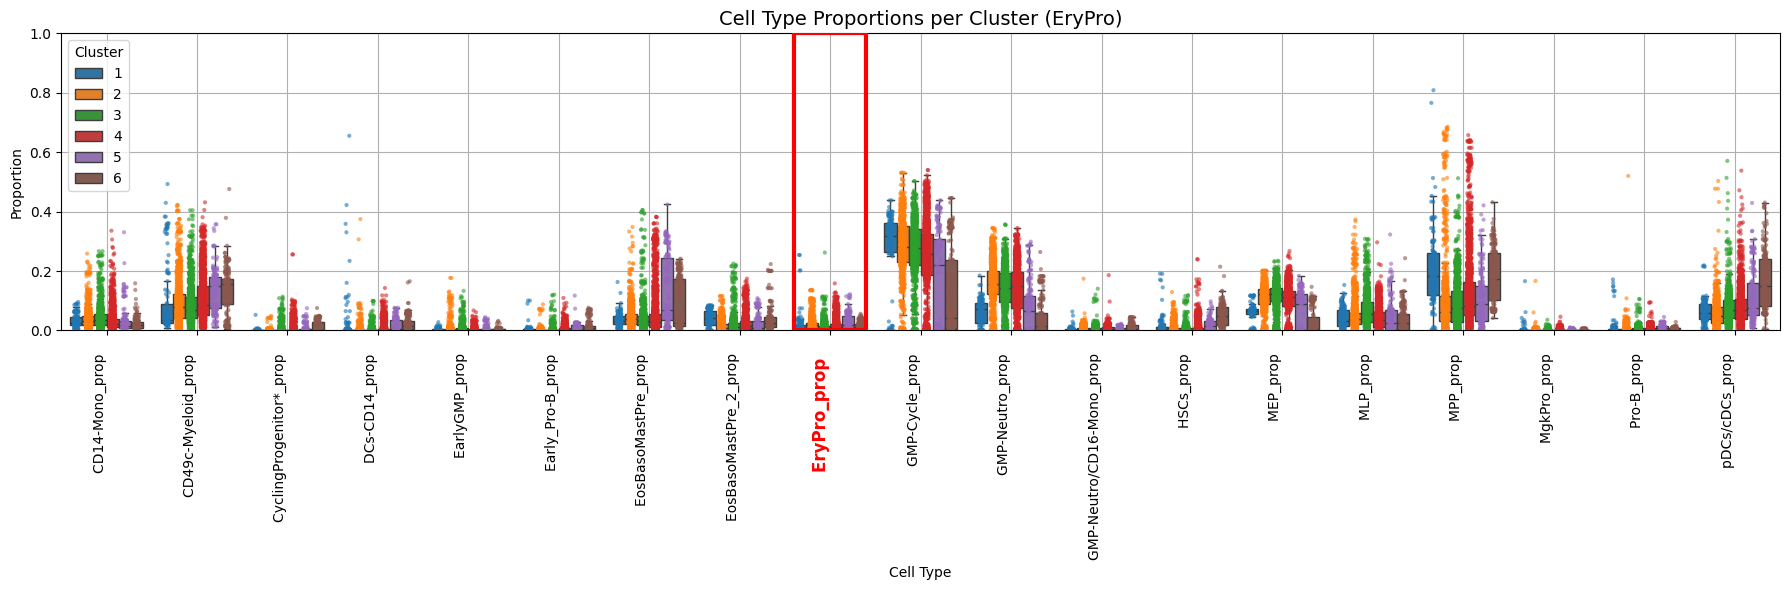

In [27]:

df_ct = ct_results_df[ct_prop_cols].copy()
# Add cluster assignments from protocol clustering
df_ct['cluster'] = clusters  # reuse protocol-based clusters

# Melt for seaborn
long_df = df_ct.melt(
    id_vars='cluster',
    var_name='cell_type',
    value_name='proportion'
)
plt.figure(figsize=(18, 6))  # wider
long_df["_x_spaced"] = long_df["cell_type"].astype(str) + "   "

ax = sns.boxplot(
    data=long_df,
    x="_x_spaced",
    y="proportion",
    hue='cluster',
    palette='tab10',
    # width=0.25,
    showfliers=False,
    dodge=True
)

sns.stripplot(
    data=long_df,
    x="_x_spaced",
    y="proportion",
    hue='cluster',
    palette='tab10',
    dodge=True,
    size=3,
    jitter=0.15,
    alpha=0.6,
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(set(clusters))], labels[:len(set(clusters))], title="Cluster")
ax.set_title(f"Cell Type Proportions per Cluster ({TARGET_CT})", fontsize=14)
ax.set_ylabel("Proportion")
ax.set_xlabel("Cell Type")
ax.set_ylim(0, 1)
ax.grid(1)

from matplotlib.patches import Rectangle

# Get x tick labels
xticks = ax.get_xticklabels()
x_labels = [t.get_text().strip() for t in xticks]

# Find index of target cell type
if TARGET_CT + "_prop" in x_labels:
    target_idx = x_labels.index(TARGET_CT+ "_prop")
    
    # Box dimensions
    box_width = 0.8   # covers the boxplot width
    y_min, y_max = ax.get_ylim()
    
    rect = Rectangle(
        (target_idx - box_width / 2, y_min),  # bottom-left
        box_width,                            # width
        y_max - y_min,                        # height
        fill=False,
        edgecolor="red",
        linewidth=3,
        zorder=10
    )
    
    ax.add_patch(rect)

    # Also highlight the label
    for label in ax.get_xticklabels():
        if label.get_text().strip() == TARGET_CT + "_prop":
            label.set_color("red")
            label.set_fontweight("bold")
            label.set_fontsize(12)

plt.tight_layout()
plt.show()


### Heatmap of protocols per cluster.

/tmp/ipykernel_3833993/197639344.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


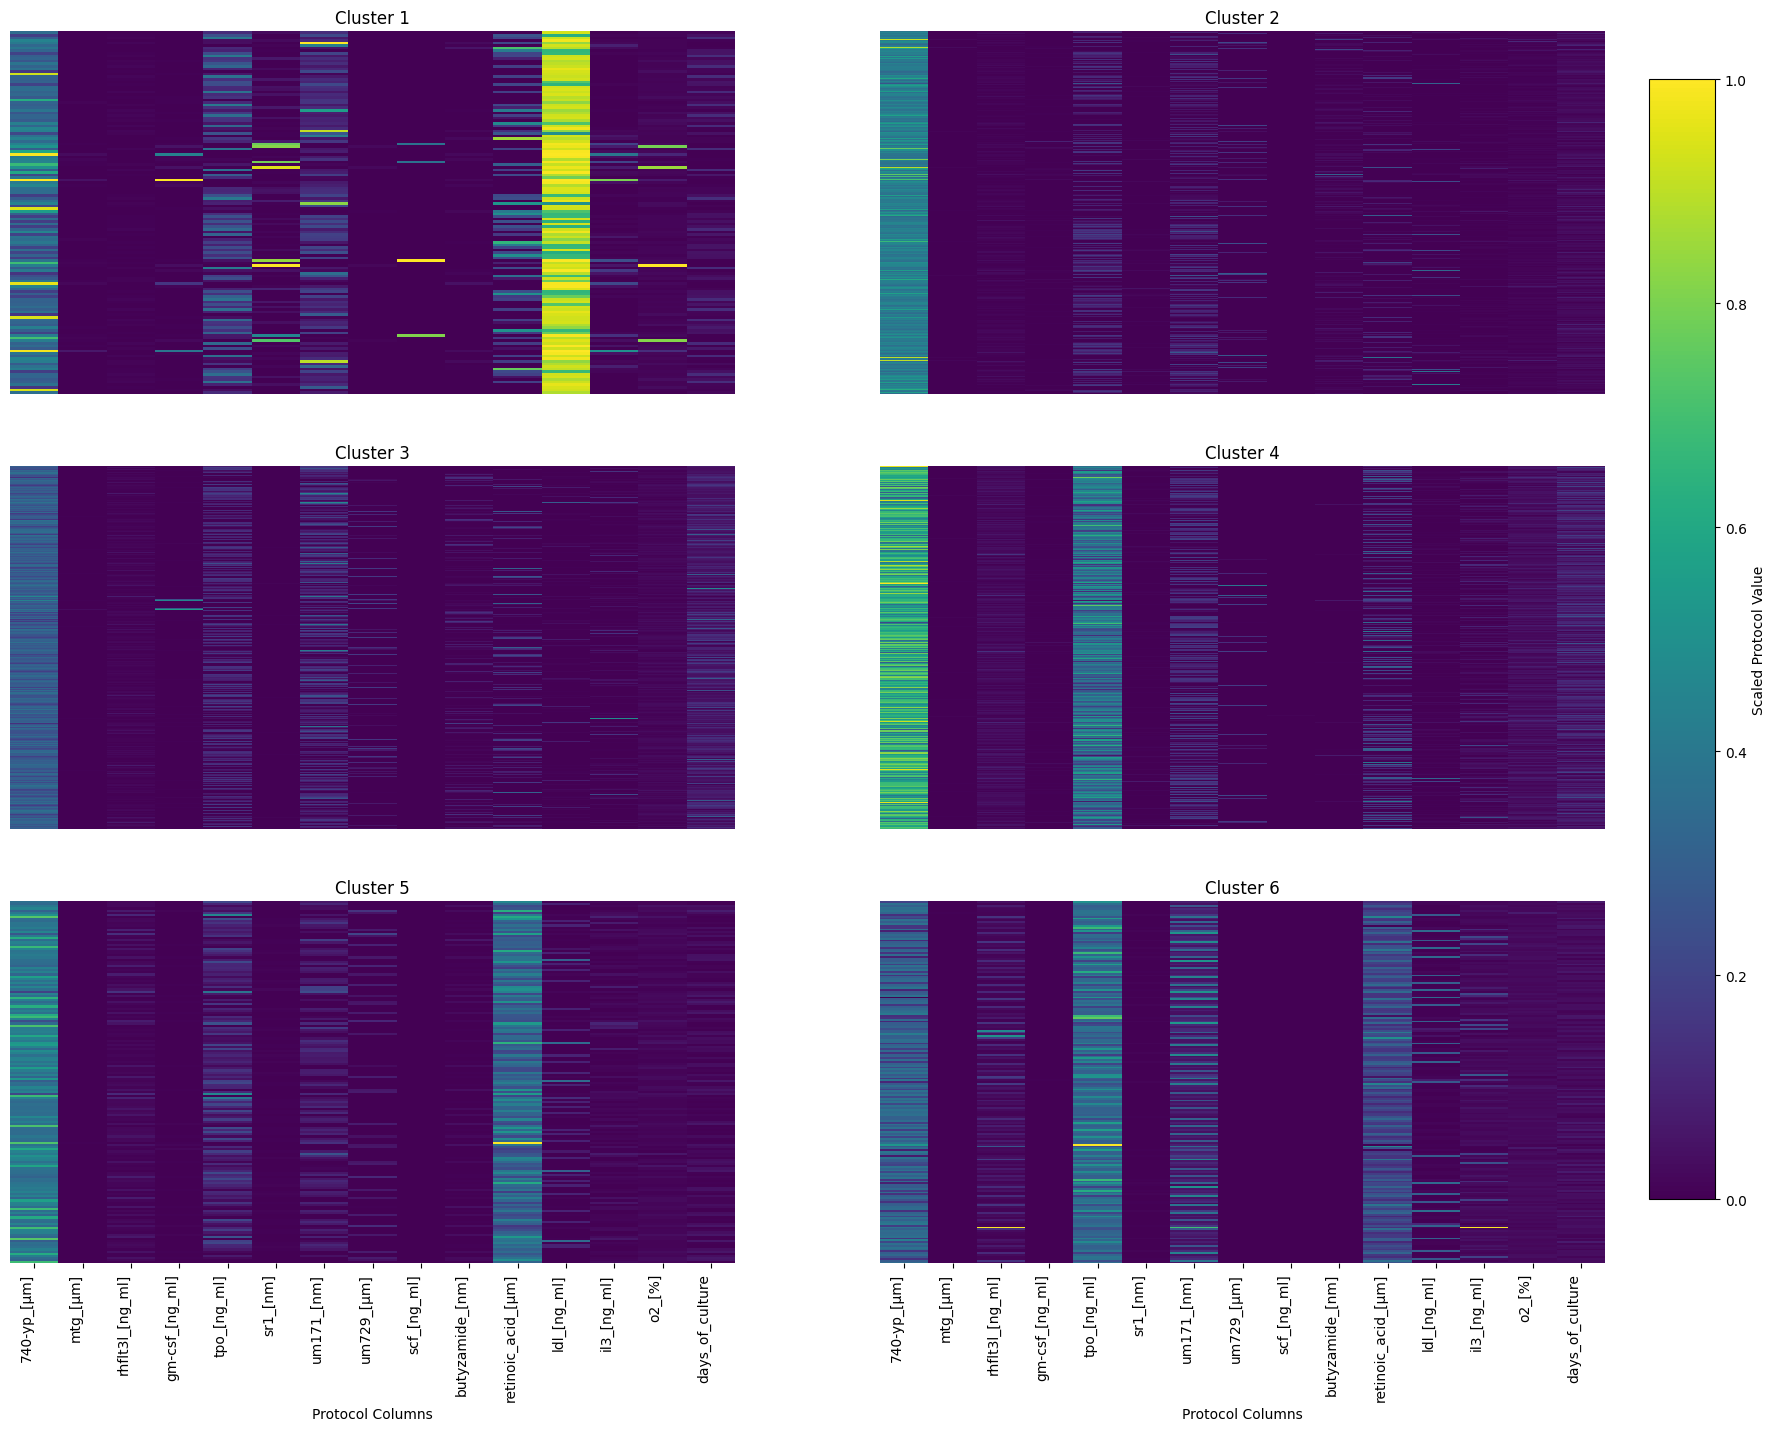

In [28]:
df_protocol = ct_results_df[protocol_cols].copy()
df_protocol['cluster'] = clusters  # reuse protocol assignments

# -----------------------------
# Global min-max scaling with edge case handling
# -----------------------------
df_scaled = df_protocol.copy()
for col in protocol_cols:
    col_min = df_protocol[col].min()
    col_max = df_protocol[col].max()
    if col_max == col_min:
        df_scaled[col] = 1.0
    else:
        df_scaled[col] = (df_protocol[col] - col_min) / (col_max - col_min)

# -----------------------------
# Facet heatmaps per cluster
# -----------------------------
cluster_labels = sorted(df_scaled['cluster'].unique())
n_clusters = len(cluster_labels)
n_cols = 2
n_rows = (n_clusters + 1) // 2

# Leave space on the right for colorbar
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 16),
    gridspec_kw={'right': 0.85}  # reserve space on right
)
axes = axes.flatten()

# Plot heatmaps
for i, cluster in enumerate(cluster_labels):
    ax = axes[i]
    cluster_df = df_scaled[df_scaled['cluster'] == cluster].copy()

    sns.heatmap(
        cluster_df[protocol_cols],
        cmap='viridis',
        cbar=False,  # disable individual colorbars
        ax=ax,
        yticklabels=False,
        xticklabels=True if cluster > n_clusters - 2 else False
    )

    ax.set_title(f"Cluster {cluster}", fontsize=12)
    if cluster > n_clusters - 2:
        ax.set_xlabel("Protocol Columns")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

# Remove unused axes
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

# -----------------------------
# Add single colorbar on the right
# -----------------------------
# Position: [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.87, 0.15, 0.03, 0.7])  # outside the grid
norm = colors.Normalize(
    vmin=df_scaled[protocol_cols].min().min(),
    vmax=df_scaled[protocol_cols].max().max()
)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])  # required for ScalarMappable
fig.colorbar(sm, cax=cbar_ax, label='Scaled Protocol Value')

plt.tight_layout()
plt.show()


### Plot loss distributio by cluster.

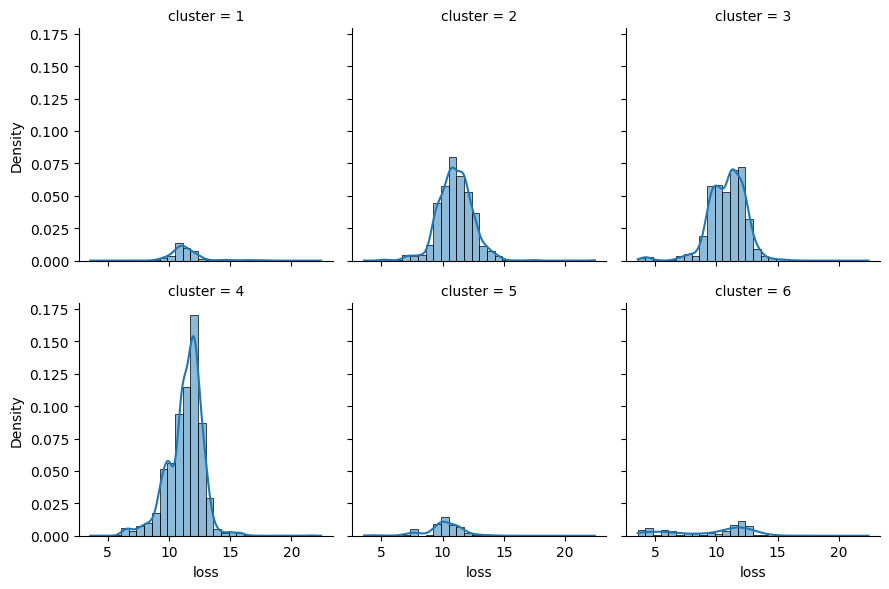

In [29]:
df_protocol_scaled["loss"] = ct_results_df["loss"]
sns.displot(
    data=df_protocol_scaled,
    x="loss",
    col="cluster",        # facet by cluster
    kind="hist",          # histogram
    stat="density",       # normalize
    bins=30,              # adjust bins as needed
    kde=True,             # add KDE curve
    height=3,
    col_wrap=3            # wrap facets
)

plt.tight_layout()
plt.show()

## Visualize Simulated Cellular Response.

### 

In [31]:
candidates_df

sample_id  \
target_ct run_id                       sample_id                                            
HSCs      2026-01-21_19-39-07_4bd2367a 0              HSCs:2026-01-21_19-39-07_4bd2367a:0   
                                       1              HSCs:2026-01-21_19-39-07_4bd2367a:1   
                                       2              HSCs:2026-01-21_19-39-07_4bd2367a:2   
                                       3              HSCs:2026-01-21_19-39-07_4bd2367a:3   
                                       4              HSCs:2026-01-21_19-39-07_4bd2367a:4   
...                                                                                   ...   
MgkPro    2026-01-21_18-21-31_e65f06d5 120        MgkPro:2026-01-21_18-21-31_e65f06d5:120   
                                       121        MgkPro:2026-01-21_18-21-31_e65f06d5:121   
                                       122        MgkPro:2026-01-21_18-21-31_e65f06d5:122   
                                       123        MgkPro:2026-01-21_18-21-31_e65f06d5:123   
                                       124        MgkPro:2026-01-21_18-21-31_e65f06d5:124   

                                                  740-yp_[µm]    mtg_[µm]  \
target_ct run_id                       sample_id                            
HSCs      2026-01-21_19-39-07_4bd2367a 0             5.557746  504.632000   
                                       1             6.192060   61.875835   
                                       2             3.798582   53.417680   
                                       3             4.560554   41.148567   
                                       4             5.212351   46.239655   
...                                                       ...         ...   
MgkPro    2026-01-21_18-21-31_e65f06d5 120           4.742057  114.453460   
                                       121           5.589697  147.114260   
                                       122           4.619626  142.696490   
                                       123           4.209705  187.589300   
                                       124           4.762968  148.481140   

                                                  rhflt3l_[ng_ml]  \
target_ct run_id                       sample_id                    
HSCs      2026-01-21_19-39-07_4bd2367a 0                 0.986312   
                                       1                 2.120808   
                                       2                14.787356   
                                       3                12.984896   
                                       4                21.085213   
...                                                           ...   
MgkPro    2026-01-21_18-21-31_e65f06d5 120              10.321251   
                                       121               4.884870   
                                       122              10.192080   
                                       123               5.827748   
                                       124              15.872105   

                                                  gm-csf_[ng_ml]  tpo_[ng_ml]  \
target_ct run_id                       sample_id                                
HSCs      2026-01-21_19-39-07_4bd2367a 0               39.196030     0.874320   
                                       1                7.684754     1.980090   
                                       2               16.131220     3.101104   
                                       3                8.468374     0.000000   
                                       4                3.963747     2.913188   
...                                                          ...          ...   
MgkPro    2026-01-21_18-21-31_e65f06d5 120              6.555941     2.883199   
                                       121             33.879990     2.170457   
                                       122              8.624926     2.967821   
                                       123              8.383217     3.030591  

In [ ]:
target_ct = "HSCs"
prop_col = f"{target_ct}_prop"
target_ct_df = concat_df.loc[concat_df["target_ct"] == target_ct].sort_values(prop_col, ascending=False)
sns.histplot(target_ct_df, x=prop_col, stat="density")
sns.kdeplot(target_ct_df, x=prop_col)

min_ct_prop = 0.15
target_ct_df = target_ct_df.loc[target_ct_df[prop_col] > min_ct_prop]
target_ct_df

### Select run to plot.

In [30]:
# run_to_plot = "2025-12-20_12-07-08_3075ebdd"
# run_to_plot = "2025-12-20_17-00-53_155b8d76"
# run_to_plot = "2025-12-20_14-19-02_f048d60d"
run_to_plot = "2026-01-20_18-22-04_a6f6656f"
run_to_plot = "2026-01-20_19-07-42_aa643c65"
run_df = candidates_df.loc[TARGET_CT, run_to_plot]
sorted_run_df = run_df.iloc[run_df["loss"].argsort()]
sorted_run_df

/tmp/ipykernel_3833993/1629802551.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  run_df = candidates_df.loc[TARGET_CT, run_to_plot]


KeyError: '2026-01-20_19-07-42_aa643c65'

### Plot histogram and kde of loss.

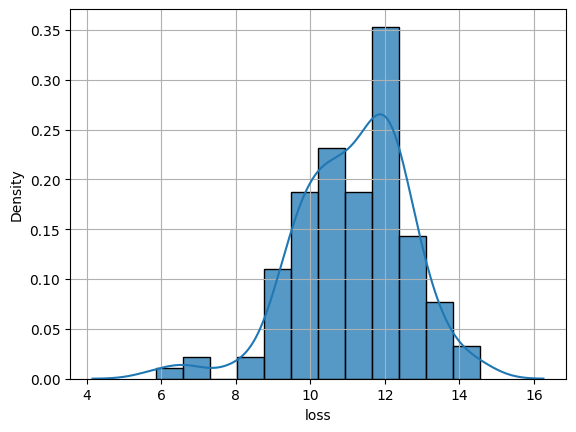

In [ ]:
sns.histplot(sorted_run_df, x="loss", stat="density")
sns.kdeplot(sorted_run_df, x="loss")
plt.grid(1)

### Scatter Plot conditions covariates and loss.

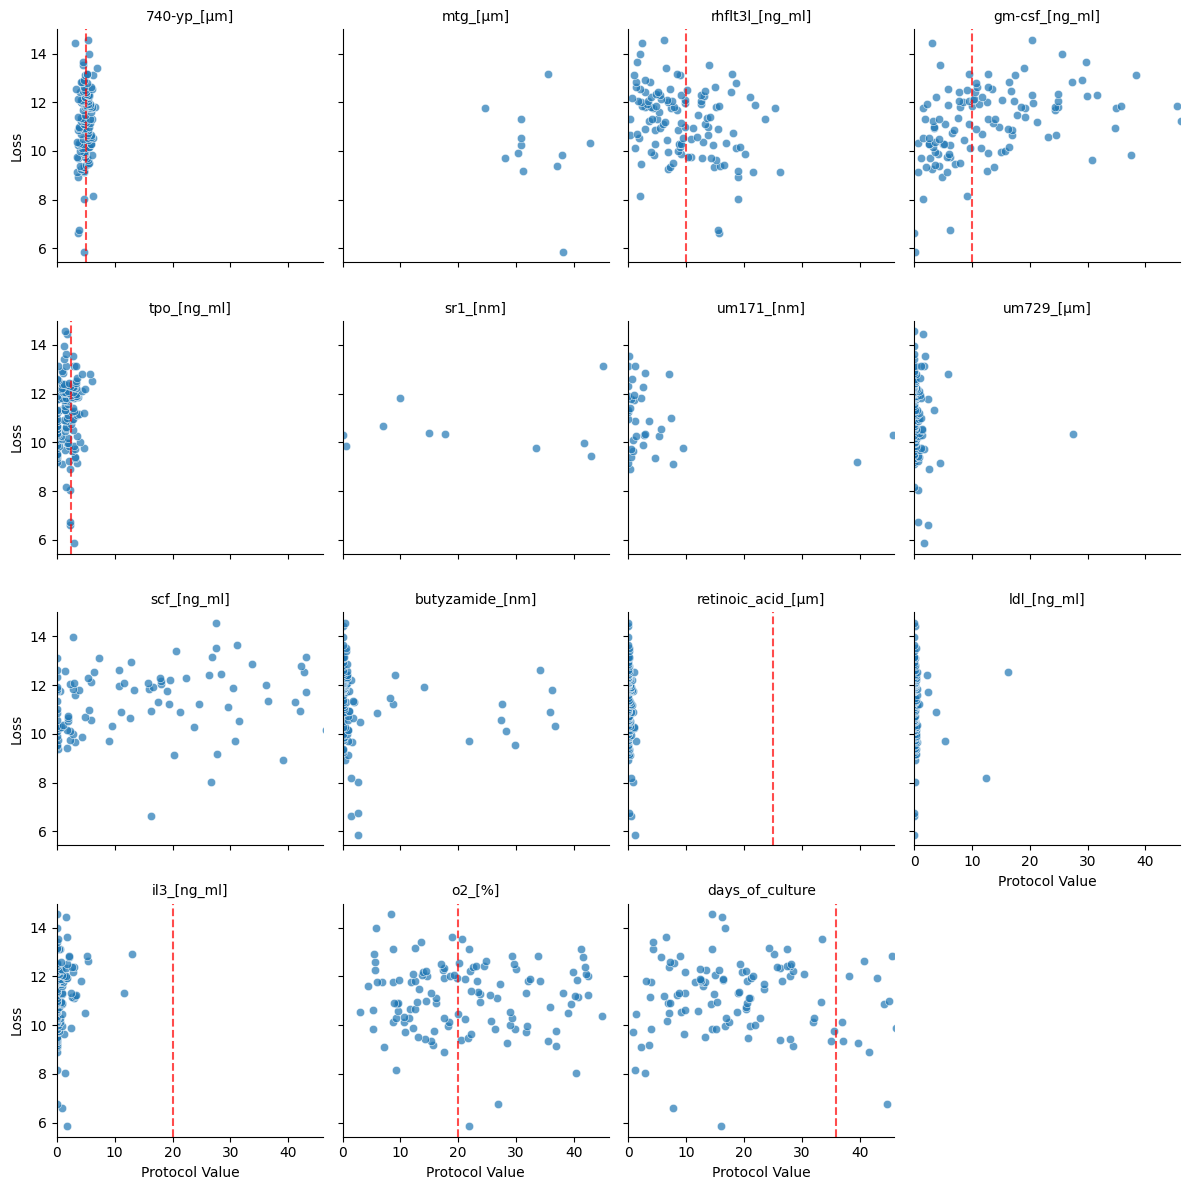

In [ ]:
# Melt protocol columns into long format
long_df = sorted_run_df.melt(
    id_vars=["loss"],            # keep loss
    value_vars=protocol_cols,    # the protocol columns
    var_name="protocol",         # new column with the protocol name
    value_name="protocol_value"  # new column with the value
)

# Optional: only non-zero values
# long_df = long_df[long_df["protocol_value"] != 0]

# Create FacetGrid
g = sns.FacetGrid(
    long_df,
    col="protocol",
    col_wrap=4,
    height=3,
    sharey=True
)

# Scatter plot
g.map_dataframe(
    sns.scatterplot,
    x="protocol_value",
    y="loss",
    alpha=0.7
)

# Add vertical line at precomputed max and set dynamic x-axis limits per facet
margin = 10  # small margin beyond max value
for ax, protocol in zip(g.axes.flat, protocol_cols):
    max_val = data_conc_max[protocol]
    ax.set_xlim(0, max_val + margin)  # dynamic x-axis cap
    ax.axvline(x=max_val, color="red", linestyle="--", alpha=0.7)

# Set axis labels and titles
g.set_axis_labels("Protocol Value", "Loss")
g.set_titles("{col_name}")

plt.tight_layout()
plt.show()


### Dimensionality reduction on the generated protocols.

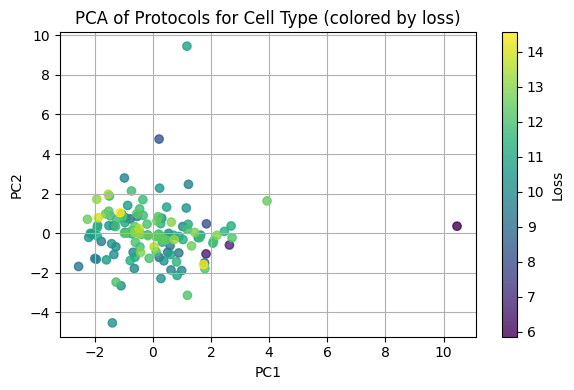

In [ ]:
# Only protocol columns
X = sorted_run_df[protocol_cols].copy()

# Optional: standardize features (recommended for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # 2D for plotting
pcs = pca.fit_transform(X_scaled)

# Create a dataframe with PCs and loss
pc_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=X.index)
pc_df["loss"] = sorted_run_df["loss"]

# Ensure loss is numeric
pc_df["loss"] = pc_df["loss"].astype(float)

plt.figure(figsize=(6,4))

# Create scatter with Matplotlib directly
sct = plt.scatter(
    x=pc_df["PC1"],
    y=pc_df["PC2"],
    c=pc_df["loss"],           # continuous values
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(sct, label="Loss")  # continuous colorbar
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Protocols for Cell Type (colored by loss)")
plt.tight_layout()
plt.grid(1)
plt.show()



### Scatter plot of real cells genes agains the generated ones.

/tmp/ipykernel_4110952/605964018.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.argsort(run_df["loss"])[0],
/tmp/ipykernel_4110952/605964018.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.argsort(run_df["loss"])[len(run_df)//4],
/tmp/ipykernel_4110952/605964018.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.argsort(run_df["loss"])[len(run_df)//2],
/tmp/ipykernel_4110952/605964018.py:5: FutureWarning: Series._

adata_gen_ct=View of AnnData object with n_obs × n_vars = 350 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'
 adata_true_ct=View of AnnData object with n_obs × n_vars = 3163 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'


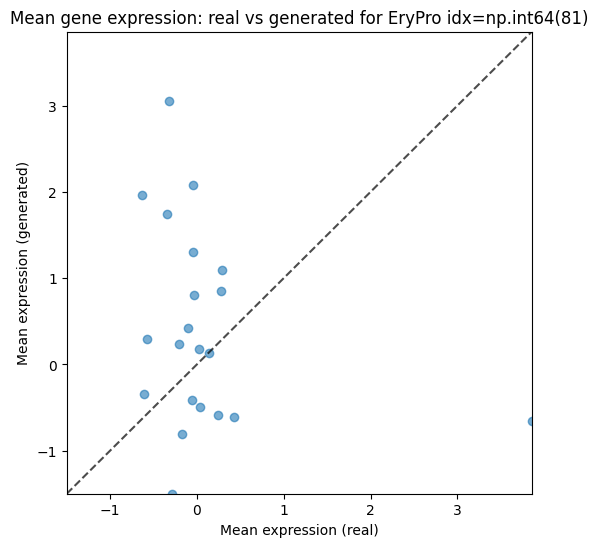

adata_gen_ct=View of AnnData object with n_obs × n_vars = 350 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'
 adata_true_ct=View of AnnData object with n_obs × n_vars = 3163 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'


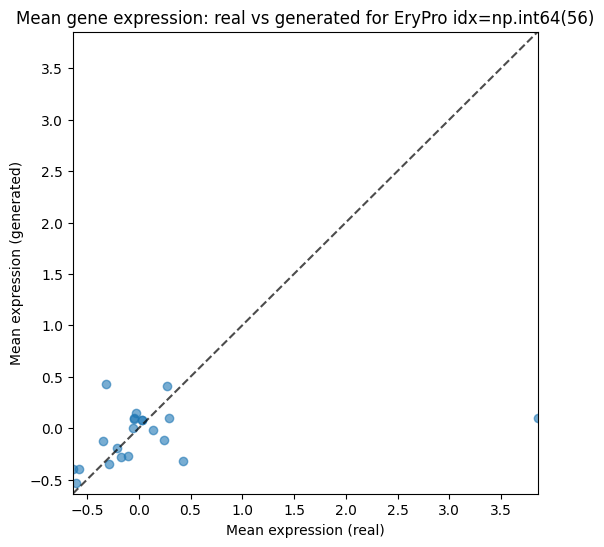

adata_gen_ct=View of AnnData object with n_obs × n_vars = 350 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'
 adata_true_ct=View of AnnData object with n_obs × n_vars = 3163 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'


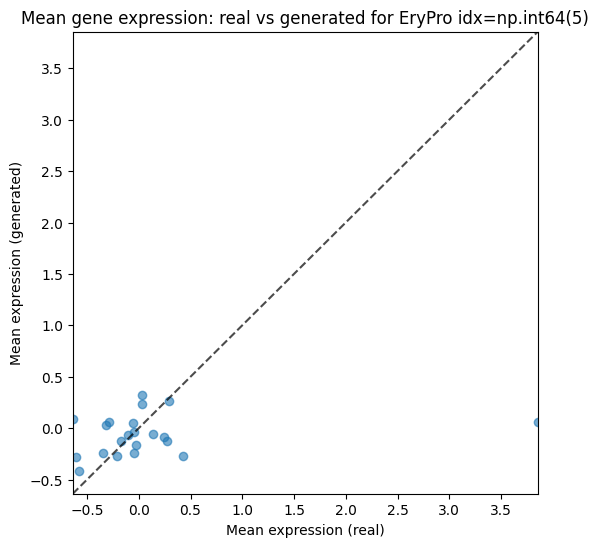

adata_gen_ct=View of AnnData object with n_obs × n_vars = 350 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'
 adata_true_ct=View of AnnData object with n_obs × n_vars = 3163 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'


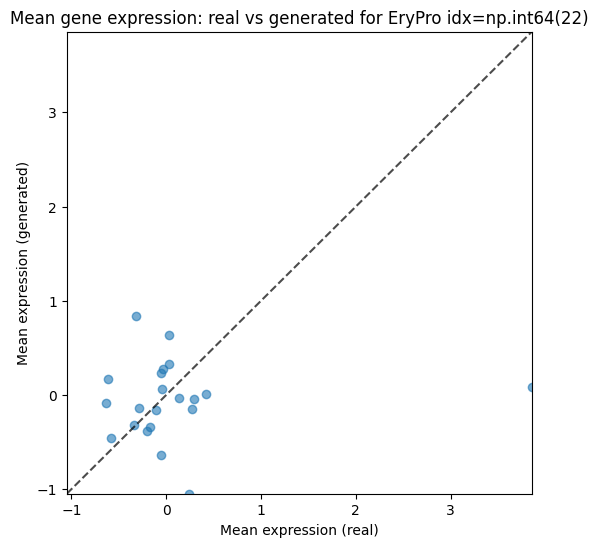

adata_gen_ct=View of AnnData object with n_obs × n_vars = 350 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'
 adata_true_ct=View of AnnData object with n_obs × n_vars = 3163 × 21
    obs: 'cell_type', 'data_type'
    obsm: 'X_scatter'


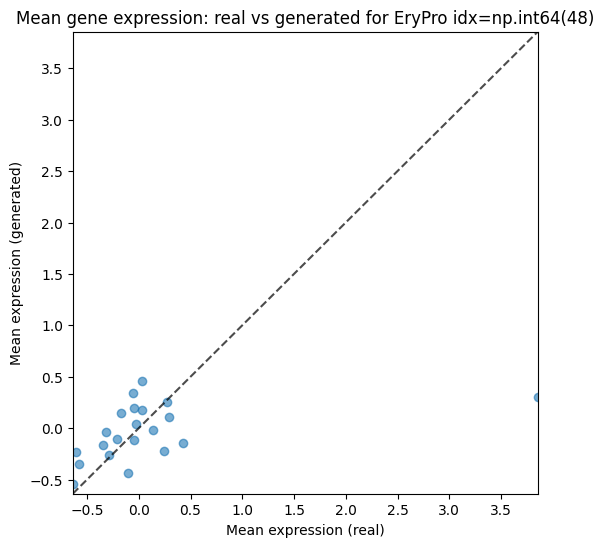

In [ ]:
idxs = [
    np.argsort(run_df["loss"])[0],
    np.argsort(run_df["loss"])[len(run_df)//4],
    np.argsort(run_df["loss"])[len(run_df)//2],
    np.argsort(run_df["loss"])[3*(len(run_df)//4)],
    np.argsort(run_df["loss"])[-1],
]
for idx in idxs:
    run_fwd = fwd_rdict[run_to_plot]
    X = adata_g.obsm["rescaled_features"]
    adata_gen = get_adata_from_idx(
        X,
        adata_g,
        ct_le,
        run_fwd,
        idx,
        compute_stuff=False,
    )
    adata_true_ct = adata_gen[(adata_gen.obs.cell_type == TARGET_CT) & (adata_gen.obs.data_type != "gen")]
    adata_gen_ct = adata_gen[adata_gen.obs.data_type == "gen"]
    print(f"{adata_gen_ct=}\n {adata_true_ct=}")

    # Compute mean gene expression per gene
    mean_real = adata_true_ct.X.mean(axis=0)
    mean_gen = adata_gen_ct.X.mean(axis=0)

    # Make scatter plot
    plt.figure(figsize=(6,6))
    plt.scatter(mean_real, mean_gen, alpha=0.6)
    plt.xlabel("Mean expression (real)")
    plt.ylabel("Mean expression (generated)")
    plt.title(f"Mean gene expression: real vs generated for {TARGET_CT} {idx=}")

    lims = [
        np.min([mean_real.min(), mean_gen.min()]),
        np.max([mean_real.max(), mean_gen.max()])
        # 20, 20
    ]
    plt.plot(lims, lims, 'k--', alpha=0.7)
    plt.xlim(lims)
    plt.ylim(lims)

    plt.show()


In [ ]:
import torch

TARGET_PROPS_DICTIONARY = {
    "HSCs": [0.07, 0.07, 0.00, 0.00, 0.07, 0.01, 0.07, 0.07, 0.00, 0.07, 0.07, 0.00, 0.21, 0.07, 0.07, 0.07, 0.00, 0.01, 0.07],
    "MgkPro": [0.05, 0.05, 0.00, 0.00, 0.05, 0.01, 0.01, 0.05, 0.00, 0.05, 0.05, 0.00, 0.05, 0.05, 0.05, 0.05, 0.42, 0.01, 0.05],
    "EryPro": [0.05, 0.05, 0.00, 0.00, 0.05, 0.01, 0.01, 0.05, 0.42, 0.05, 0.05, 0.00, 0.05, 0.05, 0.05, 0.05, 0.0, 0.01, 0.05],
}
TARGET_PROPS_DICTIONARY["HSCs"]

mask_dict = {
    "HSCs": [False, False, True, True, False, False, False, False, True, False, False, True, True, False, False, False, True, False, False],
    "MgkPro": [False, False, True, True, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False],
    "EryPro": [False, False, True, True, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False],
}
mask = mask_dict["HSCs"]
# Define loss function
loss_fns = {
    "cell_type": lambda pred, target: -torch.sum(target[..., mask]*torch.nn.functional.log_softmax(pred[..., mask], dim=-1), dim=-1)
}
prop = torch.tensor(
    TARGET_PROPS_DICTIONARY["HSCs"]
).float().to(forward_model.forward_model.device)
target = {
    "cell_type": prop.unsqueeze(0)
}
probs = torch.zeros((1, 19)).float().cuda()
probs[..., 12] = 0.21
probs[..., 0] = 1.0
loss_fns["cell_type"](probs, prop)
loss_fns["cell_type"](prop, prop)

tensor([0.3402], device='cuda:0')

In [ ]:
loss_fns["cell_type"](prop, prop)


tensor(0.3402, device='cuda:0')